In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
# Load File

df = pd.read_csv("Student_Feedback_Dataset.csv")
df.head()

,Date,Session,Session Code,Subject,Name,Gender,Roll No,Class,Semester,Faculty,Regularity,Punctuality,Clarity,Interaction,Technology,Overall Rating
0,01-01-2025,Session 1,250201,IOT,Aaryan Joshi,Male,mca2504001,MCA,Sem 2,Prof. S. Joshi,Average,Average,Average,Average,Average,3
1,01-01-2025,Session 1,250201,IOT,Mehul Desai,Male,mca2504002,MCA,Sem 2,Prof. N. Mehta,Excellent,Good,Average,Excellent,Below Average,4
2,01-01-2025,Session 1,250201,IOT,Priya Mistry,Male,mca2504003,MCA,Sem 2,Prof. A. Patel,Average,Average,Good,Below Average,Average,4
3,01-01-2025,Session 1,250201,IOT,Krishna Makwana,Male,mca2504004,MCA,Sem 2,Prof. A. Patel,Below Average,Below Average,Excellent,Average,Excellent,5
4,01-01-2025,Session 1,250201,IOT,Pooja Mehta,Female,mca2504005,MCA,Sem 2,Prof. M. Desai,Below Average,Good,Good,Below Average,Below Average,3


In [8]:
# Shape (Rows & Columns)

df.shape

(600, 16)

In [9]:
# Column Names

df.columns

Index(['Date', 'Session', 'Session Code', 'Subject', 'Name', 'Gender',
       'Roll No', 'Class', 'Semester', 'Faculty', 'Regularity', 'Punctuality',
       'Clarity', 'Interaction', 'Technology', 'Overall Rating'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            600 non-null    object
 1   Session         600 non-null    object
 2   Session Code    600 non-null    int64 
 3   Subject         600 non-null    object
 4   Name            600 non-null    object
 5   Gender          600 non-null    object
 6   Roll No         600 non-null    object
 7   Class           600 non-null    object
 8   Semester        600 non-null    object
 9   Faculty         600 non-null    object
 10  Regularity      600 non-null    object
 11  Punctuality     600 non-null    object
 12  Clarity         600 non-null    object
 13  Interaction     600 non-null    object
 14  Technology      600 non-null    object
 15  Overall Rating  600 non-null    int64 
dtypes: int64(2), object(14)
memory usage: 75.1+ KB


In [11]:
# Statistical Summary

df.describe()

,Session Code,Overall Rating
count,600.000000,600.000000
mean,250202.500000,4.013333
std,1.118967,0.819110
min,250201.000000,3.000000
25%,250201.750000,3.000000
50%,250202.500000,4.000000
75%,250203.250000,5.000000
max,250204.000000,5.000000


In [12]:
# Missing Values Check

df.isnull().sum()

Date              0
Session           0
Session Code      0
Subject           0
Name              0
Gender            0
Roll No           0
Class             0
Semester          0
Faculty           0
Regularity        0
Punctuality       0
Clarity           0
Interaction       0
Technology        0
Overall Rating    0
dtype: int64

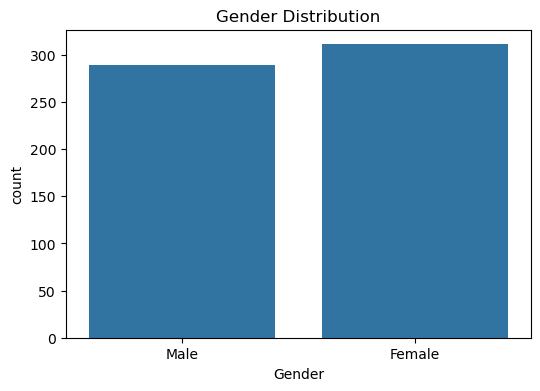

In [13]:
# Count of Gender Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.show()

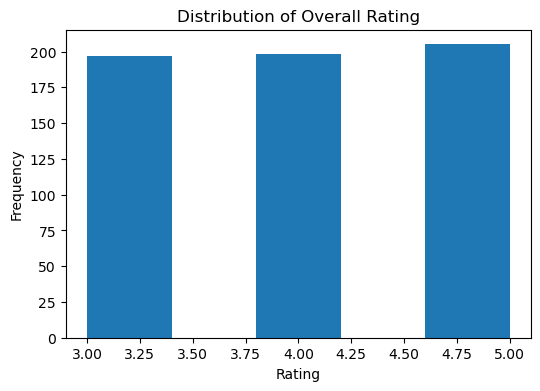

In [14]:
# Overall Rating 

plt.figure(figsize=(6,4))
plt.hist(df['Overall Rating'], bins=5)

plt.title("Distribution of Overall Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

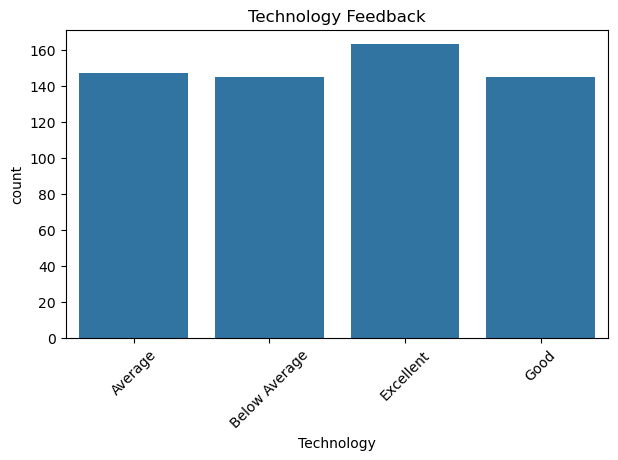

In [15]:
#  Technology Feedback Countplot

plt.figure(figsize=(7,4))
sns.countplot(x='Technology', data=df)

plt.title("Technology Feedback")
plt.xticks(rotation=45)

plt.show()

Text(0, 0.5, 'Overall Rating')

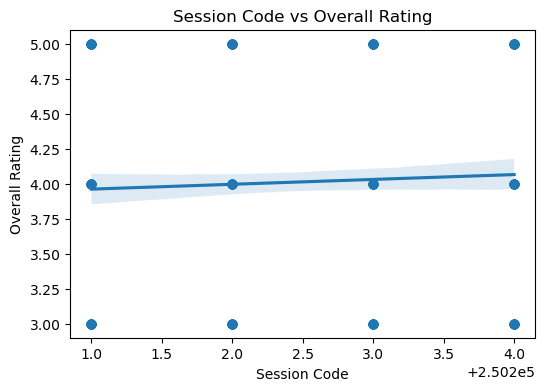

In [16]:
#  Rating vs Technology (Boxplot)

plt.figure(figsize=(6,4))

sns.regplot(x='Session Code', y='Overall Rating', data=df)

plt.title("Session Code vs Overall Rating")
plt.xlabel("Session Code")
plt.ylabel("Overall Rating")

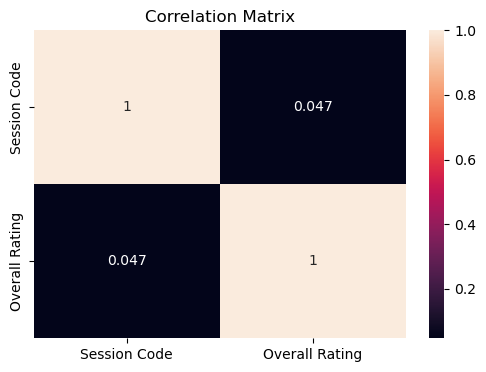

In [17]:
# correlation between Session code & Overall rating

numeric_df = df[['Session Code','Overall Rating']]
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

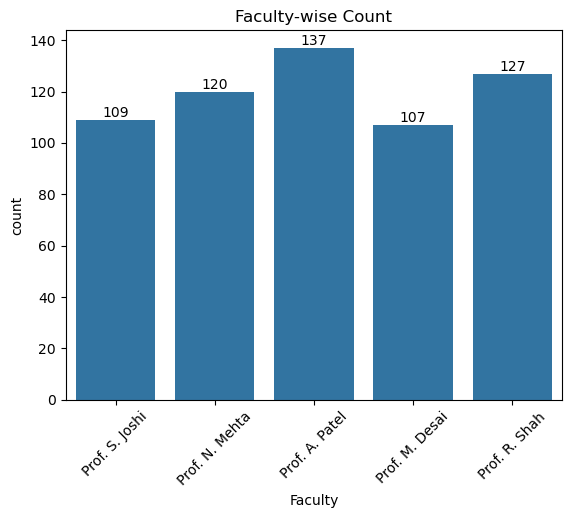

In [18]:
# Subject-wise Overall Rating

plt.figure()

ax = sns.countplot(data=df, x='Faculty')

#  Direct labels
ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title("Faculty-wise Count")

plt.show()

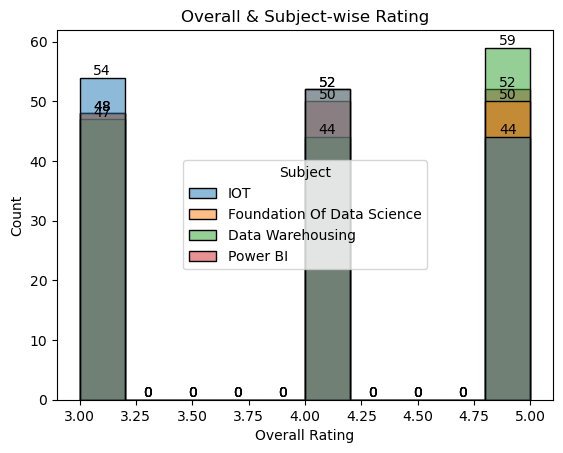

In [31]:
plt.figure()

# Histogram with subject-wise using hue
ax = sns.histplot(data=df, x='Overall Rating', hue='Subject', bins=10, multiple='layer')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Overall & Subject-wise Rating")
plt.show()


In [32]:
tech_rating = df.groupby('Technology')['Overall Rating'].mean().reset_index()

tech_rating

,Technology,Overall Rating
0,Average,4.000000
1,Below Average,3.951724
2,Excellent,4.092025
3,Good,4.000000


In [33]:
# Scaling

scaler = StandardScaler()
scaled = scaler.fit_transform(tech_rating[['Overall Rating']])

# KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
clusters=kmeans.fit_predict(scaled)
tech_rating

C:\Users\Jay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Technology,Overall Rating
0,Average,4.000000
1,Below Average,3.951724
2,Excellent,4.092025
3,Good,4.000000


In [34]:
# Subject Clustering

subject_group = df.groupby('Subject')['Overall Rating'].mean().reset_index()

scaled = scaler.fit_transform(subject_group[['Overall Rating']])
subject_group['Cluster'] = kmeans.fit_predict(scaled)

print(subject_group)

                      Subject  Overall Rating  Cluster
0            Data Warehousing        4.080000        2
1  Foundation Of Data Science        4.013333        1
2                         IOT        3.933333        0
3                    Power BI        4.026667        1


C:\Users\Jay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [35]:
daily = df.groupby(['Faculty', 'Date'])['Overall Rating'].agg(['min','max','mean']).reset_index()

print(daily.head())

          Faculty       Date  min  max      mean
0  Prof. A. Patel 2025-01-01    3    5  3.750000
1  Prof. A. Patel 2025-01-02    3    4  3.333333
2  Prof. A. Patel 2025-01-03    3    5  3.833333
3  Prof. A. Patel 2025-01-04    4    4  4.000000
4  Prof. A. Patel 2025-01-05    3    5  4.000000


In [36]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Day'] = df['Date'].dt.date
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month

In [37]:
# Faculty-wise Daily Analysis

daily = df.groupby(['Faculty', 'Day'])['Overall Rating'].agg(['min','max','mean']).reset_index()
print(daily)

            Faculty         Day  min  max      mean
0    Prof. A. Patel  2025-01-01    3    5  3.750000
1    Prof. A. Patel  2025-01-02    3    4  3.333333
2    Prof. A. Patel  2025-01-03    3    5  3.833333
3    Prof. A. Patel  2025-01-04    4    4  4.000000
4    Prof. A. Patel  2025-01-05    3    5  4.000000
..              ...         ...  ...  ...       ...
141  Prof. S. Joshi  2025-01-26    3    5  4.000000
142  Prof. S. Joshi  2025-01-27    4    5  4.600000
143  Prof. S. Joshi  2025-01-28    3    5  4.250000
144  Prof. S. Joshi  2025-01-29    3    5  4.000000
145  Prof. S. Joshi  2025-01-30    4    5  4.500000

[146 rows x 5 columns]


In [38]:
# Weekly Analysis

weekly = df.groupby(['Faculty', 'Week'])['Overall Rating'].agg(['min','max','mean']).reset_index()
print(weekly)

           Faculty  Week  min  max      mean
0   Prof. A. Patel     1    3    5  3.777778
1   Prof. A. Patel     2    3    5  4.115385
2   Prof. A. Patel     3    3    5  3.857143
3   Prof. A. Patel     4    3    5  4.150000
4   Prof. A. Patel     5    3    5  4.111111
5   Prof. M. Desai     1    3    5  3.941176
6   Prof. M. Desai     2    3    5  3.692308
7   Prof. M. Desai     3    3    5  4.266667
8   Prof. M. Desai     4    3    5  4.222222
9   Prof. M. Desai     5    3    5  3.875000
10  Prof. N. Mehta     1    3    5  4.157895
11  Prof. N. Mehta     2    3    5  4.103448
12  Prof. N. Mehta     3    3    5  3.851852
13  Prof. N. Mehta     4    3    5  3.966667
14  Prof. N. Mehta     5    3    5  4.200000
15   Prof. R. Shah     1    3    5  3.826087
16   Prof. R. Shah     2    3    5  4.066667
17   Prof. R. Shah     3    3    5  3.931034
18   Prof. R. Shah     4    3    5  4.000000
19   Prof. R. Shah     5    3    5  4.200000
20  Prof. S. Joshi     1    3    5  3.869565
21  Prof. 

In [39]:
# Monthly Analysis

monthly = df.groupby(['Faculty', 'Month'])['Overall Rating'].agg(['min','max','mean']).reset_index()
print(monthly)

          Faculty  Month  min  max      mean
0  Prof. A. Patel      1    3    5  4.014599
1  Prof. M. Desai      1    3    5  4.009346
2  Prof. N. Mehta      1    3    5  4.033333
3   Prof. R. Shah      1    3    5  3.992126
4  Prof. S. Joshi      1    3    5  4.018349


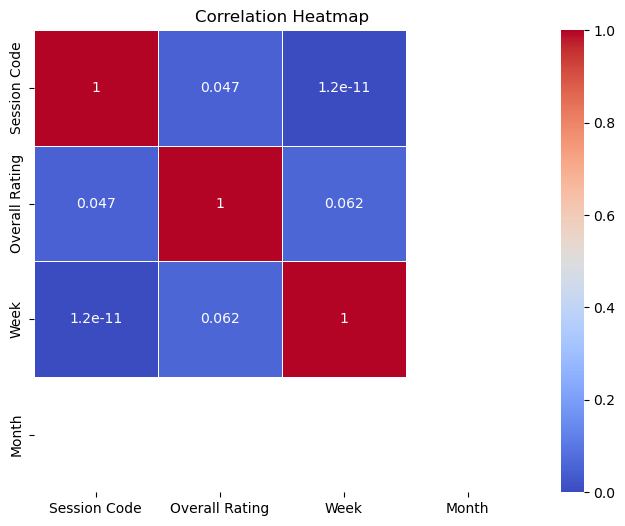

In [40]:
# Heatmap Code

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [41]:
df.nunique()

Date               30
Session             4
Session Code        4
Subject             4
Name              429
Gender              2
Roll No           600
Class               1
Semester            3
Faculty             5
Regularity          4
Punctuality         4
Clarity             4
Interaction         4
Technology          4
Overall Rating      3
Day                30
Week                5
Month               1
dtype: int64